In [0]:
%pip install tensorflow

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Dense, Input, SimpleRNN 

In [0]:
sentences = [
    "This product is very good.",
    "I got a lot of benefit from this product.",
    "Its quality is quite good.",
    "The price is a bit high, but the quality is also good.",
    "Delivery time was very fast.",
    "Packaging was impressive.",
    "Customer service was helpful.",
    "Product description was absolutely correct.",
    "I liked the color of this product.",
    "Size was perfect.",
    "Its design is unique.",
    "Durability is also good.",
    "It is easy to use.",
    "It is value for money.",
    "Got the warranty.",
    "Return policy was convenient.",
    "Its performance was better than expected.",
    "I was not disappointed with this product.",
    "Recommended to friends as well.",
    "Its material is of high quality.",
    "Features are quite useful.",
    "Installation was simple.",
    "Instructions were clear.",
    "Its look is stylish.",
    "Battery life is good.",
    "Noise level is low.",
    "Maintenance is easy.",
    "Its weight is lightweight.",
    "Brand is reliable.",
    "After sales service was good.",
    "Its price is reasonable.",
    "I did not face any problem with this product.",
    "Its finish is smooth.",
    "Its performance was average.",
    "I expected a little better.",
    "Its smell is a bit strong.",
    "Its color faded.",
    "Its size is a bit small.",
    "Its quality is somewhat compromised.",
    "Its delivery was late.",
    "Its packaging was damaged.",
    "Customer support was slow.",
    "Its return process was complicated.",
    "Its warranty claim was difficult.",
    "Its price is overpriced.",
    "Its design is outdated.",
    "Its material is of low quality.",
    "Its performance was poor.",
    "I was disappointed with this product.",
    "I will not recommend this product.",
    "I love this product",
]
labels = [1]*15 + [0]*15
labels = np.array(labels)

In [0]:
vocab_size = 2000
tok = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tok.fit_on_texts(sentences)
seqs = tok.texts_to_sequences(sentences)
maxlen = max(len(s) for s in seqs)
X = pad_sequences(seqs,maxlen=maxlen,padding='post')
y=labels

In [0]:
X[45]

array([  3,  29,   2, 111,   0,   0,   0,   0,   0,   0,   0,   0],
      dtype=int32)

In [0]:
embed_dim =16
rnn_units=8


In [0]:
inp=Input(shape=(maxlen,),dtype='int32',name='input')
x=Embedding(input_dim=vocab_size,output_dim=embed_dim,mask_zero=True,name='embed')(inp)
rnn=SimpleRNN(units=rnn_units,return_sequences=False,return_state=False,name='simple_rnn')
x_last = rnn(x)
out=Dense(1,activation='sigmoid',name='out')(x_last)
model=Model(inputs=inp,outputs=out)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 12)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 12, 16)    │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 12)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,209 (125.82 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
model.fit(X[:len(y)], y, epochs=25, batch_size=8, verbose=1)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.1268 
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.1158
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1072
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0986
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0908
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0842 
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0784 
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0732
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0680 
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0637 
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0597
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0564
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


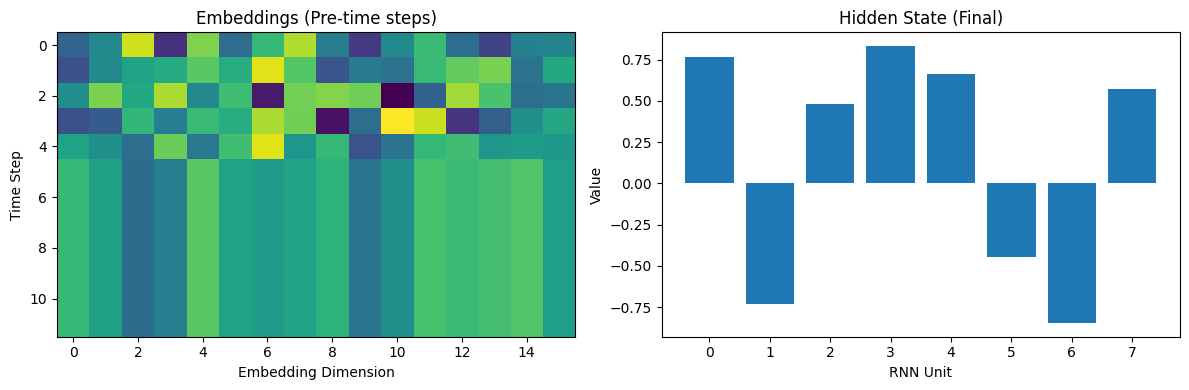

In [0]:
# Create an intermediate model to output pre-time steps and hidden states from SimpleRNN
intermediate_model = Model(inputs=inp, outputs=[x, x_last])

# Get embeddings and hidden state for a sample input
sample_input = X[0:1]
embeddings, hidden_state = intermediate_model.predict(sample_input)

# Visualize embeddings (pre-time steps) and hidden state
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(embeddings[0], aspect='auto', cmap='viridis')
plt.title('Embeddings (Pre-time steps)')
plt.xlabel('Embedding Dimension')
plt.ylabel('Time Step')

plt.subplot(1, 2, 2)
plt.bar(range(len(hidden_state[0])), hidden_state[0])
plt.title('Hidden State (Final)')
plt.xlabel('RNN Unit')
plt.ylabel('Value')

plt.tight_layout()
plt.show()